# Jaguar Re-ID — CNN Improved v4

**Architecture** : 5x(Conv2D + BatchNorm + MaxPool2D) → GlobalAveragePooling2D → Dropout(0.5) → Dense(128) → Dense(31)  
**Improvement over Baseline** : +BatchNorm, 5 blocs (32→64→128→256→512), Dropout(0.5), augmentation moderate  
**Diff vs v3** : augmentation heavy→moderate (isole l'effet de l'architecture 5 blocs + Dropout 0.5)

## 1. Setup & data loading

In [1]:
import sys, os, glob
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

# GPU setup — LD_LIBRARY_PATH must be set before TF loads CUDA
nvidia_libs = glob.glob(os.path.join(sys.prefix, 'lib/python*/site-packages/nvidia/*/lib'))
if nvidia_libs:
    os.environ['LD_LIBRARY_PATH'] = ':'.join(nvidia_libs) + ':' + os.environ.get('LD_LIBRARY_PATH', '')
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Memory growth — avoid grabbing all VRAM at once (other processes may be running)
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

from src.config import *
from src.data import load_data, load_test_pairs, make_dataset

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU: {gpus}")
if not gpus:
    print("WARNING: No GPU detected, training will be slow on CPU!")
    print("Run this in terminal first: export LD_LIBRARY_PATH=$(python3 -c \"import glob; print(':'.join(glob.glob('env/lib/python*/site-packages/nvidia/*/lib')))\")")
    print("Then restart the Jupyter kernel.")

I0000 00:00:1775841667.195623  243647 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
MODEL_NAME   = 'cnn_improved_v4'
AUGMENTATION = 'moderate'
#   'none'     → raw images
#   'light'    → flip horizontal
#   'moderate' → flip + brightness + contrast
#   'heavy'    → flip + rotation + zoom + brightness + contrast

In [3]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
test_pairs_df = load_test_pairs()

train_ds = make_dataset(X_train, y_train, training=True, augmentation=AUGMENTATION)
val_ds   = make_dataset(X_val, y_val)

print(f"Train: {X_train.shape} | Val: {X_val.shape}")
print(f"Train batches: {len(train_ds)} | Val batches: {len(val_ds)}")

I0000 00:00:1775841676.657375  243647 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 26501 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:86:00.0, compute capability: 8.6


Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3)
Train batches: 48 | Val batches: 12


## 2. Model architecture

In [4]:
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(256, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(512, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name=MODEL_NAME)
    return model

model = build_model()
model.summary()

Model: "cnn_improved_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 31)             │         3,999 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,642,207 (6.26 MB)

 Trainable params: 1,640,223 (6.26 MB)

 Non-trainable params: 1,984 (7.75 KB)

## 3. Hyperparameter sweep

On teste plusieurs learning rates, on garde le meilleur.

In [5]:
def train_and_eval(lr, run_name):
    m = build_model()
    m.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, MODEL_NAME, run_name)
    hist = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=10, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir),
        ],
        verbose=0
    )
    _, val_acc = m.evaluate(val_ds, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return {'val_acc': val_acc, 'best_epoch': best_epoch, 'hist': hist.history}

In [6]:
lr_candidates = [1e-2, 1e-3, 1e-4]

results = {}
print(f"=== LR sweep ({MODEL_NAME}) ===")
for lr in lr_candidates:
    run_name = f'lr_{lr}'
    results[run_name] = train_and_eval(lr, run_name)

=== LR sweep (cnn_improved_v4) ===


I0000 00:00:1775841687.724096  243922 service.cc:153] XLA service 0x7ff4f003db10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775841687.724154  243922 service.cc:161]   StreamExecutor [0]: NVIDIA RTX A6000, Compute Capability 8.6 (Driver: 12.6.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1775841688.028746  243922 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775841688.712246  243922 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1775841688.838702  243922 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5269__.88
I0000 00:00:1775841696.011492  243922 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:0

  lr_0.01: val_acc=0.8865 (best epoch=86)


I0000 00:00:1775842096.636275  243923 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_83009__.88
I0000 00:00:1775842106.885783  243920 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_83009__.88


  lr_0.001: val_acc=0.9024 (best epoch=46)


I0000 00:00:1775842315.465664  243916 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_130753__.88
I0000 00:00:1775842325.442496  243923 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_130753__.88


  lr_0.0001: val_acc=0.9024 (best epoch=98)


In [7]:
rows = [{'Config': name, 'Val Accuracy': r['val_acc'], 'Best Epoch': r['best_epoch']}
        for name, r in results.items()]
results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

BEST_CONFIG = results_df.iloc[0]['Config']
BEST_LR = float(BEST_CONFIG.split('_')[1])
BEST_EPOCH = int(results_df.iloc[0]['Best Epoch'])
print(f"\nBest: {BEST_CONFIG} \u2192 val_acc={results_df.iloc[0]['Val Accuracy']:.4f}")

,Config,Val Accuracy,Best Epoch
0,lr_0.001,0.902375,46
1,lr_0.0001,0.902375,98
2,lr_0.01,0.886544,86



Best: lr_0.001 → val_acc=0.9024


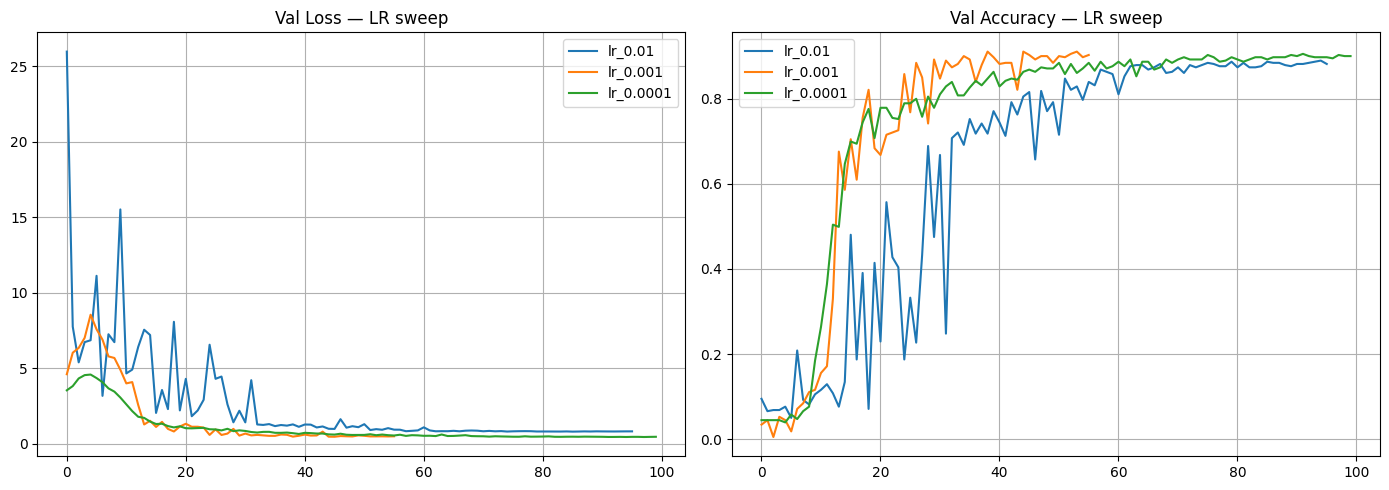

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['hist']['val_loss'],     label=name)
    axes[1].plot(r['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss \u2014 LR sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy \u2014 LR sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_lr_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation (best config)

In [9]:
model = build_model()
model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'best_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    ],
    verbose=1
)

Epoch 1/100


I0000 00:00:1775842686.927517  243916 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_212714__.88


47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.1141 - loss: 3.4355

I0000 00:00:1775842696.736547  243922 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_212714__.88


48/48 ━━━━━━━━━━━━━━━━━━━━ 24s 292ms/step - accuracy: 0.1636 - loss: 3.0921 - val_accuracy: 0.0897 - val_loss: 5.2517 - learning_rate: 0.0010
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.2810 - loss: 2.5355 - val_accuracy: 0.0079 - val_loss: 5.9004 - learning_rate: 0.0010
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.3384 - loss: 2.2889 - val_accuracy: 0.0237 - val_loss: 5.7075 - learning_rate: 0.0010
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.4235 - loss: 2.0183 - val_accuracy: 0.0580 - val_loss: 4.7957 - learning_rate: 0.0010
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.5079 - loss: 1.7352 - val_accuracy: 0.0264 - val_loss: 5.4474 - learning_rate: 0.0010
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.5515 - loss: 1.5817 - val_accuracy: 0.1082 - val_loss: 6.0740 - learning_rate: 0.0010
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.5917 - loss: 1.4420 - val_accura

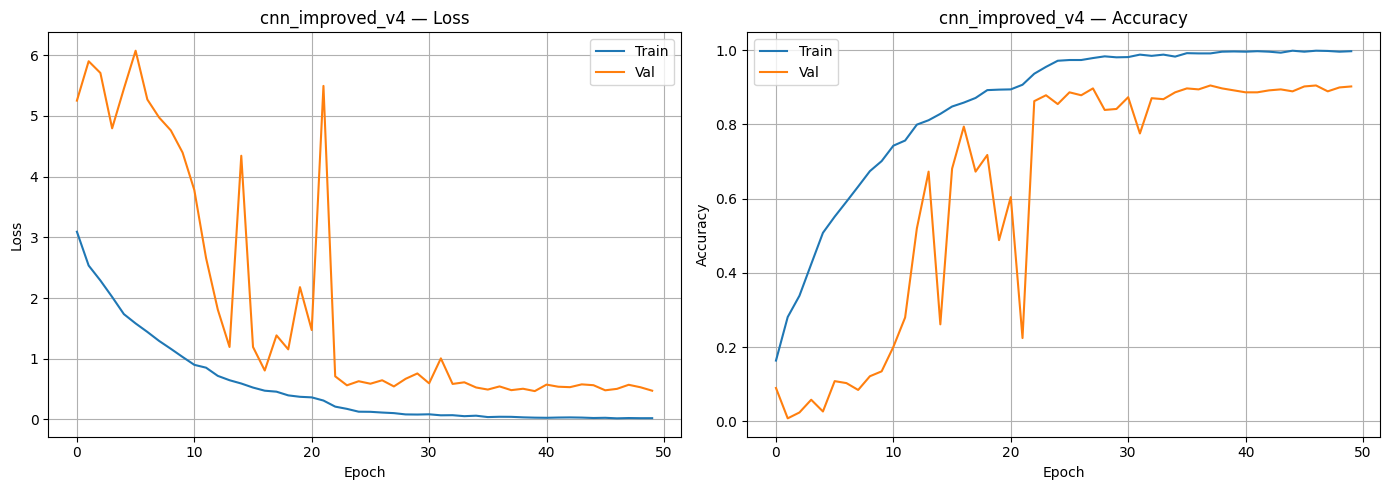

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{MODEL_NAME} \u2014 Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{MODEL_NAME} \u2014 Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc     = model.evaluate(val_ds, verbose=0)

print(f"{MODEL_NAME} (best LR={BEST_LR}):")
print(f"  Train \u2014 Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   \u2014 Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

cnn_improved_v4 (best LR=0.001):
  Train — Loss: 0.0121, Acc: 1.0000
  Val   — Loss: 0.4673, Acc: 0.8918


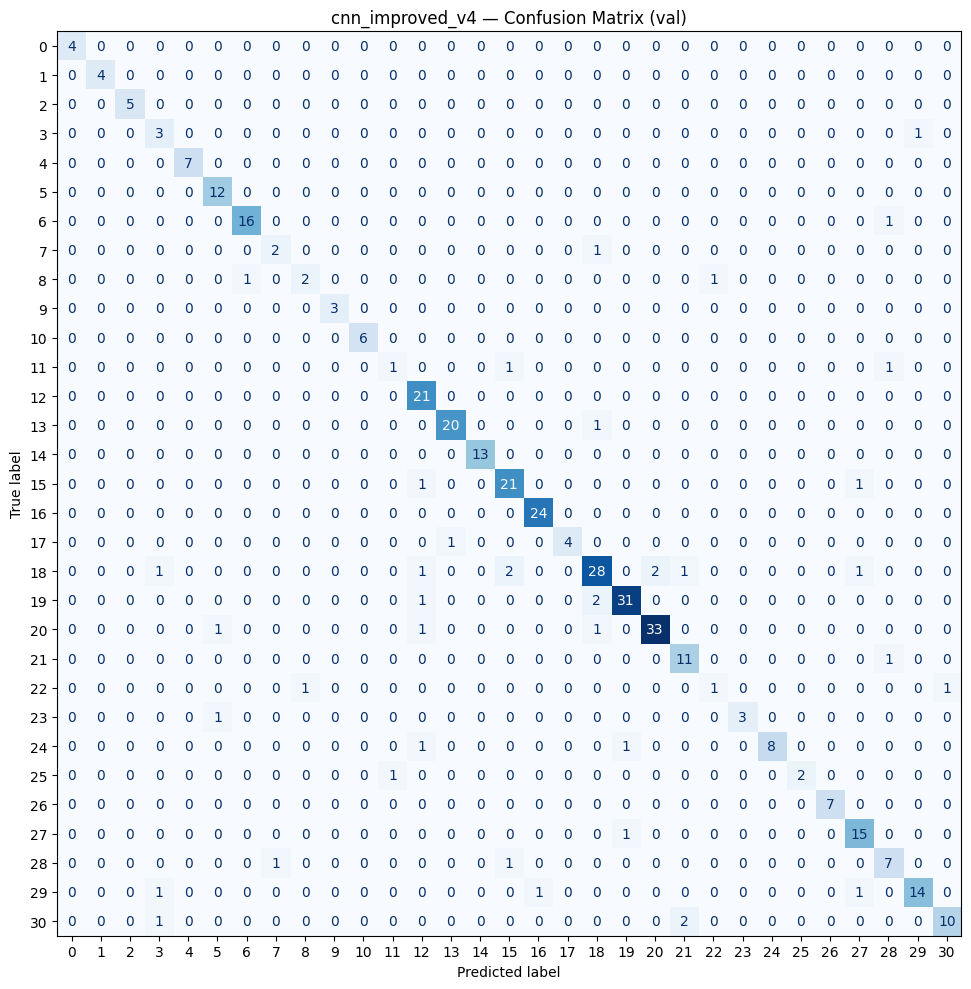

In [12]:
y_val_pred = model.predict(val_ds, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{MODEL_NAME} \u2014 Confusion Matrix (val)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Kaggle submission

In [13]:
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
all_ds = make_dataset(X_all, y_all, training=True, augmentation=AUGMENTATION)

print(f"Retraining on full dataset ({len(X_all)} images) for {BEST_EPOCH} epochs")

final_model = build_model()
final_model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_model.fit(
    all_ds, epochs=BEST_EPOCH,
    callbacks=[callbacks.TensorBoard(log_dir=final_log)],
    verbose=1
)
print(f"Final train acc: {final_model.evaluate(all_ds, verbose=0)[1]:.4f}")

Retraining on full dataset (1895 images) for 46 epochs
Epoch 1/46


I0000 00:00:1775842950.148066  243922 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_488261__.88


59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.1286 - loss: 3.3119

I0000 00:00:1775842961.043776  243920 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_488261__.88


60/60 ━━━━━━━━━━━━━━━━━━━━ 38s 435ms/step - accuracy: 0.1752 - loss: 2.9763
Epoch 2/46
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.3145 - loss: 2.4378
Epoch 3/46
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.3863 - loss: 2.1336
Epoch 4/46
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.4770 - loss: 1.8847
Epoch 5/46
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.5214 - loss: 1.6203
Epoch 6/46
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.6127 - loss: 1.3805
Epoch 7/46
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.6317 - loss: 1.2821
Epoch 8/46
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.6881 - loss: 1.1042
Epoch 9/46
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.7224 - loss: 0.9743
Epoch 10/46
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.7472 - loss: 0.8746
Epoch 11/46
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.7858 - loss: 0.7484
Epoch 12/46
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.8174 -

In [14]:
X_test, test_filenames = load_data('test')

inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = inp
for layer in final_model.layers[:-1]:
    x = layer(x)
embedding_model = keras.Model(inputs=inp, outputs=x, name=f'{MODEL_NAME}_embedding')

test_embeddings = embedding_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

del X_test  # free memory

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

# Chunked to avoid OOM on high-dim embeddings
CHUNK = 1000
similarities = np.empty(len(query_idx), dtype=np.float32)
for start in range(0, len(query_idx), CHUNK):
    sl = slice(start, start + CHUNK)
    q = test_embeddings_norm[query_idx[sl]]
    g = test_embeddings_norm[gallery_idx[sl]]
    similarities[sl] = np.clip((q * g).sum(axis=1), 0, 1)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 327ms/step
Embedding shape: (371, 128)
Saved: /HomeSweetHome/FHuang5/Developer/kaggle_jaguar_classification/submissions/submission_cnn_improved_v4.csv


,row_id,similarity
0,0,0.873416
1,1,0.612256
2,2,0.620434
3,3,0.671050
4,4,0.683498


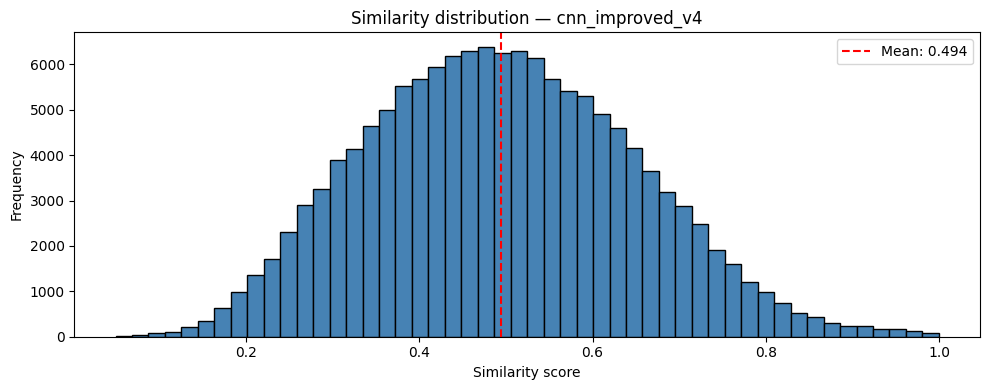

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution \u2014 {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Observations & Verdict

### Résultats

| Métrique | Train | Val |
|----------|-------|-----|
| Accuracy | 1.0000 | 0.8918 |
| Loss     | 0.0121 | 0.4673 |
| Overfitting ? | — | Oui, gap = 10.8 pts |
| Kaggle Score (public) | — | 0.387 |
| Kaggle Score (private) | — | 0.393 |

### Comparaison vs v3

| Métrique | v3 | v4 | Diff |
|----------|----|----|------|
| Sweep best val_acc | 0.8786 | 0.9024 | **+2.4 pts** |
| Section 4 val_acc | 0.8892 | 0.8918 | +0.3 pts |
| Gap overfitting | 9.8 pts | 10.8 pts | +1.0 pts |
| Final train acc (retrain) | 0.3113 | 0.9657 | **+65.4 pts** |
| Kaggle public | 0.292 | 0.387 | **+0.095** |
| Kaggle private | 0.298 | 0.393 | **+0.095** |

Toutes les métriques sont en hausse, surtout le **final train acc** qui passe de 31% à 96.6% — le retrain final converge enfin correctement. Le score Kaggle fait un bond de +9.5 pts, confirmant que le problème de v3 était bien l'augmentation heavy et non l'architecture.

**Fait notable** : la val_acc (89.18%) reste inférieure à v2 (90.77%, −1.6 pts), mais le score Kaggle dépasse v2 (0.387 vs 0.361, +2.6 pts). L'architecture 5 blocs classifie légèrement moins bien mais produit des **embeddings plus discriminants** pour la re-ID par similarité cosinus.

### Analyse des hyperparamètres — modification par modification

#### 1. Data Augmentation heavy → moderate — confirmation de l'hypothèse v3

Seule modification entre v3 et v4. Le retour à moderate (flip + brightness + contrast, sans rotation ni zoom) récupère **+2.4 pts de sweep val_acc** et **+9.5 pts de Kaggle**.

**Preuve chiffrée** :
- Sweep val_acc : 87.86% (v3 heavy) → 90.24% (v4 moderate) → le modèle apprend mieux sans les déformations géométriques
- Final train acc : 31.13% → 96.57% → le retrain sans ReduceLROnPlateau converge maintenant, car les images sont exploitables par le réseau
- Kaggle : 0.292 → 0.387 → les embeddings viennent d'un modèle correctement entraîné

**Verdict** : L'hypothèse de v3 est **confirmée**. Le heavy augmentation (rotation ±8°, zoom ±10%) était trop agressif pour 1516 images. Les rotations déformaient les contours des rosettes, le zoom perdait des zones discriminantes. Le moderate est le bon dosage pour ce dataset.

#### 2. Dropout 0.5 (inchangé vs v3) — maintenant évaluable, effet mitigé

En v3, le Dropout 0.5 était masqué par le heavy augmentation. En v4, on peut enfin l'évaluer : le gap d'overfitting est de 10.8 pts (train 100% vs val 89.18%).

**Comparaison avec v2** (Dropout 0.3, 4 blocs) : gap = 8.6 pts. Le gap a augmenté de +2.2 pts malgré le Dropout plus fort. Mais attention : le modèle a aussi un 5e bloc conv (+1.2M params), ce qui augmente mécaniquement la capacité d'overfitting. Le Dropout 0.5 compense partiellement cette capacité supplémentaire.

**Verdict** : Effet **neutre à légèrement positif**. Le Dropout 0.5 n'a pas réduit l'overfitting vs v2, mais il contient un modèle 4× plus gros (1.64M vs 427K params). Sans ce Dropout, le gap serait probablement bien supérieur à 10.8 pts.

#### 3. 5e bloc conv 512 filtres (inchangé vs v3) — enfin évaluable, résultat contrasté

Le 5e bloc (512 filtres, 7×7 feature maps) produit un embedding plus riche : 512 dimensions avant le Dense(128), vs 256 en v2. Le modèle passe de 427K à 1.64M params.

**Classification** : val_acc 90.24% vs v2 91.56% → **−1.3 pts**. Le réseau plus profond ne classifie pas mieux, probablement parce que 31 classes de jaguars ne nécessitent pas autant de capacité.

**Re-ID (Kaggle)** : 0.387/0.393 vs v2 0.361/0.343 → **+2.6/+5.0 pts**. L'embedding 512→128 capture des features plus fines qui améliorent la similarité cosinus entre images du même individu.

**Verdict** : **Positif pour la tâche cible (re-ID)**. La classification n'est qu'un proxy — c'est le score Kaggle qui compte. Le 5e bloc apporte un gain réel sur la re-ID (+2.6 pts public).

#### 4. LR schedule — 4 réductions, EarlyStopping à epoch 50

Le training utilise 4 réductions de LR : epoch 22 (→5e-4), 33 (→2.5e-4), 45 (→1.25e-4), 50 (→6.25e-5). EarlyStopping déclenché à epoch 50, best epoch restauré.

**Comparaison v2** : 7 réductions, best epoch 55. Le modèle v4 converge plus vite (best epoch 46 au sweep vs 55 en v2) malgré plus de paramètres, grâce au Dropout 0.5 qui régularise l'apprentissage.

### Verdict

- [x] Improvable → Instructions pour v5
- [ ] Not Improvable → Plafond atteint
- [ ] Dead-end → On abandonne cette architecture

**Justification** : Le score Kaggle (0.387/0.393) est le meilleur obtenu jusqu'ici, mais l'overfitting (10.8 pts) et l'écart entre val_acc et v2 montrent qu'il reste de la marge. Le modèle a 1.64M params pour 1516 images (1082 params/image) — la régularisation peut encore être renforcée.

**Instructions pour v5** :
- **Ajouter de la régularisation L2** (`kernel_regularizer=l2(1e-4)`) sur les couches Conv2D : le Dropout seul ne suffit pas à contenir 1.64M params, le L2 pénalisera les poids excessifs et devrait réduire le gap de 10.8 pts
- **Garder Dropout 0.5** : complémentaire au L2 (Dropout régularise les activations, L2 régularise les poids)
- **Garder l'architecture 5 blocs** : elle produit les meilleurs embeddings pour la re-ID (+2.6 pts Kaggle vs v2)
- **Garder augmentation moderate** : dosage validé en v2 et confirmé en v4

### Interprétation

_Ce notebook confirme l'analyse de v3 : le heavy augmentation était le seul responsable de la régression. En ne changeant qu'une variable (heavy → moderate), on récupère +9.5 pts de Kaggle et +65 pts de final train acc. L'architecture 5 blocs + Dropout 0.5, qui n'avait jamais pu être évaluée en conditions favorables, se révèle meilleure que v2 pour la re-ID malgré une classification légèrement inférieure. C'est un résultat important : la val_acc (proxy) et le Kaggle score (tâche réelle) ne sont pas toujours corrélés — un modèle plus profond peut produire des embeddings plus discriminants même s'il classifie un peu moins bien._